# 03 · Bus bunching – deep EDA, data verdicts & prediction set-up (Challenge #7)

Same discipline as the course notebooks (*diagnose before you touch it*): **test** each data quirk, turn it into a **verdict**, then build the model on top of it.

**Scope:** Carris Metropolitana corridors (Mira-Sintra, Caneças, EN10, Sesimbra) with GTFS schedule joined, plus Carris (Lisbon) × Waze.
**Inputs:** `_processed/corridor_pings.parquet`, `_processed/stop_passages.parquet`, `_processed/vehicles_bus_only/`, GTFS for agencies 41 & 43, Waze CSV.
**Output:** `_processed/passages_v2.parquet` = stop passages **with schedule, delay, headway, scheduled headway and headway ratio** (the `stop_passages` + `headways` shared tables).

In [1]:
import os, glob, warnings
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 40)

ROOT = os.environ.get('BB_ROOT', '../..')          # = the '#7 Detect and prevent bus bunching' folder
PROC = f'{ROOT}/_processed'
PLANS = {'LA77N': '20251002_41_YEAR_03_47_02', 'YA15B': '20250924_43_YEAR_04_05_01'}
TZ = 'Europe/Lisbon'
BUNCH = 0.5          # headway ratio threshold used for the model label (0.25 is too rare at line level, see §4)

def cramers_v(t):
    chi2 = chi2_contingency(t)[0]; n = t.values.sum(); r, k = t.shape
    phi2 = max(0, chi2/n - (k-1)*(r-1)/(n-1)); rc = r-(r-1)**2/(n-1); kc = k-(k-1)**2/(n-1)
    return float(np.sqrt(phi2/min(kc-1, rc-1)))

def hav(a, b, c, d):
    a, b, c, d = map(np.radians, [a, b, c, d])
    return 2*6371000*np.arcsin(np.sqrt(np.sin((c-a)/2)**2 + np.cos(a)*np.cos(c)*np.sin((d-b)/2)**2))

## 1 · Load pings + GTFS schedule (only trips we actually observed)

In [2]:
C = pd.read_parquet(f'{PROC}/corridor_pings.parquet')
seen = set(C.trip_id.unique())
tr, st, sp = [], [], []
for a, p in PLANS.items():
    P = f'{ROOT}/operation-plans/{p}'
    t = pd.read_csv(f'{P}/trips.txt', dtype=str, usecols=['trip_id','route_id','pattern_id','direction_id','block_id','service_id'])
    tr.append(t[t.trip_id.isin(seen)])
    s = pd.read_csv(f'{P}/stop_times.txt', dtype={'trip_id':str,'stop_id':str},
                    usecols=['trip_id','departure_time','stop_id','stop_sequence','shape_dist_traveled','timepoint'])
    st.append(s[s.trip_id.isin(seen)])
    sp.append(pd.read_csv(f'{P}/stops.txt', dtype=str, usecols=['stop_id','stop_name','stop_lat','stop_lon']))
tr, st, sp = pd.concat(tr), pd.concat(st), pd.concat(sp).drop_duplicates('stop_id')
h, m_, s_ = st.departure_time.str.split(':', expand=True).astype(int).T.values
st['sched_s'] = h*3600 + m_*60 + s_          # GTFS times can exceed 24:00 -> keep as seconds from service-day midnight
print(C.shape, '| trips seen', len(seen), '| matched in GTFS', st.trip_id.nunique())

(1174827, 11) | trips seen 2754 | matched in GTFS 2423


## 2 · Data-quality checks (pings)

In [3]:
C = C.sort_values(['vehicle_id','created_at']).reset_index(drop=True)
g = C.groupby('vehicle_id')
C['dt'] = g.created_at.diff()/1000
C['dd'] = hav(C.latitude, C.longitude, g.latitude.shift(), g.longitude.shift())
seq = st[['trip_id','stop_id','stop_sequence']].drop_duplicates(['trip_id','stop_id'])
X = C.merge(seq, on=['trip_id','stop_id'], how='left')
X['dseq'] = X.groupby(['vehicle_id','trip_id']).stop_sequence.diff()
checks = {
  'duplicate (vehicle, created_at)': C.duplicated(['vehicle_id','created_at']).mean(),
  'ping interval median (s)': C.dt.median(),
  'implied speed >120 km/h (GPS jump)': ((C.dd/C.dt*3.6) > 120).mean(),
  'stationary pings (<3 m moved)': (C.dd < 3).mean(),
  'stop_id not in GTFS stops': (~C.stop_id.isin(sp.stop_id)).mean(),
  'trip_id not in GTFS (stale plan)': (~C.trip_id.isin(set(st.trip_id))).mean(),
  'stop_id not on its own trip pattern': X.stop_sequence.isna().mean(),
  'stop_sequence goes backwards (flicker)': (X.dseq < 0).mean(),
  'stop_sequence skips >=3 stops': (X.dseq >= 3).mean(),
}
pd.Series(checks).round(4).to_frame('value')

,value
"duplicate (vehicle, created_at)",0.0000
ping interval median (s),10.0000
implied speed >120 km/h (GPS jump),0.0016
stationary pings (<3 m moved),0.2406
stop_id not in GTFS stops,0.0072
trip_id not in GTFS (stale plan),0.1494
stop_id not on its own trip pattern,0.1570
stop_sequence goes backwards (flicker),0.0049
stop_sequence skips >=3 stops,0.0026


**Verdict:** pings are clean enough (no dups left, 0.2 % GPS jumps → drop). The two real problems are **stale GTFS** (≈15 % of pings) and **`stop_id` flicker** (next-stop toggles back and forth → *fake* stop passages, see §4).

## 3 · Missingness mechanism (Technique 1 from the course, applied to our data)
Two kinds of 'missing': (a) trips with **no schedule match**, (b) trips only **partly observed** (geofence).

In [4]:
S = pd.read_parquet(f'{PROC}/stop_passages.parquet')
n0 = len(S)
# FIX: stop_id flicker creates repeated passages of the same trip at the same stop -> keep last
S = S.sort_values('t_pass').drop_duplicates(['operational_date','trip_id','vehicle_id','stop_id'], keep='last')
print(f'flicker passages removed: {n0-len(S)} ({(n0-len(S))/n0:.1%})')
S = S.merge(st[['trip_id','stop_id','stop_sequence','sched_s','timepoint']].drop_duplicates(['trip_id','stop_id']), on=['trip_id','stop_id'], how='left')
S = S.merge(tr[['trip_id','pattern_id','direction_id','block_id']], on='trip_id', how='left')
S['t'] = pd.to_datetime(S.t_pass, unit='ms', utc=True).dt.tz_convert(TZ)
S['hour'] = S.t.dt.hour; S['dow'] = pd.to_datetime(S.operational_date.astype(str)).dt.dayofweek
S['matched'] = S.sched_s.notna()
rows = [{'what': 'trip has no GTFS match', 'vs': c, 'cramers_v': round(cramers_v(pd.crosstab(~S.matched, S[c])), 3)} for c in ['line','corr','hour','dow']]
pd.DataFrame(rows)

flicker passages removed: 9617 (5.9%)


,what,vs,cramers_v
0,trip has no GTFS match,line,0.763
1,trip has no GTFS match,corr,0.232
2,trip has no GTFS match,hour,0.074
3,trip has no GTFS match,dow,0.096


In [5]:
print('unmatched share by line (worst):', S.groupby('line').matched.apply(lambda x: 1-x.mean()).sort_values(ascending=False).head(6).round(2).to_dict())
S['nstops'] = S.groupby('trip_id').stop_sequence.transform('max')
cov = S[S.matched].groupby(['operational_date','trip_id']).agg(obs=('stop_id','nunique'), n=('nstops','first'), corr=('corr','first'), hour=('hour','min'), dow=('dow','first'))
cov['low'] = cov.obs/cov.n < 0.5
print('trip coverage quantiles:', (cov.obs/cov.n).quantile([.1,.25,.5,.75]).round(2).to_dict())
pd.DataFrame([{'what':'trip <50% observed','vs':c,'cramers_v':round(cramers_v(pd.crosstab(cov.low, cov[c])),3)} for c in ['corr','hour','dow']])

unmatched share by line (worst): {'3116': 1.0, '3650': 1.0, '3103': 0.99, '3118': 0.24, '3721': 0.23, '3223': 0.22}
trip coverage quantiles: {0.1: 0.22, 0.25: 0.51, 0.5: 0.73, 0.75: 1.0}


,what,vs,cramers_v
0,trip <50% observed,corr,0.334
1,trip <50% observed,hour,0.007
2,trip <50% observed,dow,0.278


**Verdicts**
* *No GTFS match* is **structural (V≈0.76 with line)**, not random: lines 3103, 3116, 3650 ≈100 % unmatched (timetable changed), 3118/3721/3223 ≈ 23 %. → Don't impute a schedule; either get the Sept-2026 GTFS or use *observed* headway for those lines only, with a flag.
* *Partial coverage* depends on **corridor and day** (geofence + missing zone-days, e.g. Tuesday) but **not on hour (V≈0)** → time-of-day analysis is safe. A missing leader must never be read as a 'big gap': only build headways from pairs where **both buses were observed** at that stop.

## 4 · Schedule-based headways (the core table)

In [6]:
day0 = pd.to_datetime(S.operational_date.astype(str)).dt.tz_localize(TZ)
S['sched_ts'] = ((day0 - pd.Timestamp('1970-01-01', tz='UTC')).dt.total_seconds()*1000).astype('int64') + S.sched_s*1000
S['delay_s'] = (S.t_pass - S.sched_ts)/1000
S['pat'] = S.pattern_id.fillna(S['dir'])
S = S.sort_values(['operational_date','pat','stop_id','t_pass'])
g = S.groupby(['operational_date','pat','stop_id'])
S['hw'] = g.t_pass.diff()/1000; S['lead_trip'] = g.trip_id.shift(); S['lead_delay'] = g.delay_s.shift()
S['sched_hw'] = (S.sched_ts - g.sched_ts.shift())/1000
S['ratio'] = S.hw/S.sched_hw
S = S.sort_values(['operational_date','stop_id','t_pass'])            # corridor level: any corridor line at the same stop
g2 = S.groupby(['operational_date','stop_id'])
S['hw_any'] = g2.t_pass.diff()/1000; S['lead_line_any'] = g2.line.shift(); S['sched_hw_any'] = (S.sched_ts - g2.sched_ts.shift())/1000
S.drop(columns=['t']).to_parquet(f'{PROC}/passages_v2.parquet')

m = S[S.matched & (S.delay_s.abs() < 3600)].copy(); m['pos'] = m.stop_sequence/m.nstops
v = m[(m.sched_hw > 0) & (m.lead_delay.abs() < 3600)].copy(); v['b'] = v.ratio < BUNCH
print('delay (s) quantiles:', m.delay_s.quantile([.05,.25,.5,.75,.95]).round(0).to_dict())
print(f'line-level pairs {len(v)} | ratio<0.25: {(v.ratio<.25).mean():.2%} | ratio<0.5: {v.b.mean():.2%} | gap ratio>1.5: {(v.ratio>1.5).mean():.2%}')
v.groupby('corr').agg(pairs=('b','size'), bunched_lt05=('b','mean'), bunched_lt025=('ratio', lambda x: (x<.25).mean())).round(3)

delay (s) quantiles: {0.05: -663.0, 0.25: -168.0, 0.5: 60.0, 0.75: 315.0, 0.95: 964.0}
line-level pairs 111015 | ratio<0.25: 0.80% | ratio<0.5: 2.63% | gap ratio>1.5: 2.39%


,pairs,bunched_lt05,bunched_lt025
corr,,,
Caneças/Pontinha,17496,0.029,0.011
EN10,45332,0.015,0.004
Mira-Sintra/Cacém,27825,0.049,0.015
Sesimbra/Q.Conde,20362,0.017,0.004


⚠️ **Correction to yesterday's numbers:** with the flicker fix and the *scheduled* headway as reference, the ranking flips — **Mira-Sintra/Cacém (line 1715) is the worst corridor at line level**, Sesimbra looked worst only because of the observed-median reference. Line-level bunching (<0.25) is rare (~1 %) because headways are 25–40 min.

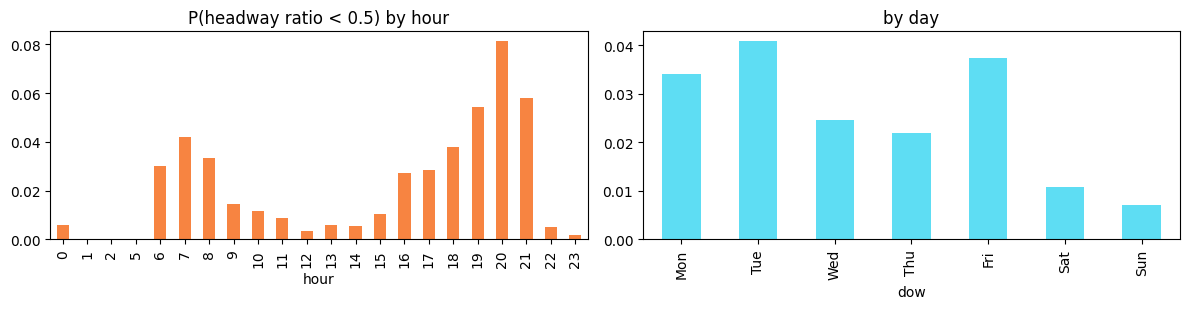

corr(line scheduled headway, bunch rate) = -0.68


,n,bunch,sched_hw_min
line,,,
1715,17534,0.062,30.0
3721,5585,0.059,30.0
1709,7895,0.039,25.0
1219,5032,0.037,30.0
1710,5332,0.030,30.0
3118,3291,0.027,55.0
3508,14933,0.025,30.0
1218,5259,0.018,30.0


In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
v.groupby('hour').b.mean().plot.bar(ax=ax[0], color='#F78441'); ax[0].set_title('P(headway ratio < 0.5) by hour')
v.groupby('dow').b.mean().rename(index=dict(enumerate('Mon Tue Wed Thu Fri Sat Sun'.split()))).plot.bar(ax=ax[1], color='#5EDDF3'); ax[1].set_title('by day')
plt.tight_layout(); plt.show()
L = v.groupby('line').agg(n=('b','size'), bunch=('b','mean'), sched_hw_min=('sched_hw', lambda x: x.median()/60)).query('n>500').sort_values('bunch', ascending=False)
print('corr(line scheduled headway, bunch rate) =', round(L[['sched_hw_min','bunch']].corr().iloc[0,1], 2)); L.head(8).round(3)

### 4b · Corridor level: how much bunching is *planned* by the timetable?

In [8]:
c = m[m.hw_any.notna() & m.sched_hw_any.notna()]
b = c[c.hw_any < 120]
print(f'passages with another corridor bus <2 min ahead: {len(b)/len(c):.1%}')
print(f'  of these, SCHEDULED <2 min apart: {(b.sched_hw_any.abs()<120).mean():.1%} | scheduled 2-5 min: {b.sched_hw_any.abs().between(120,300).mean():.1%} | >5 min (operational): {(b.sched_hw_any.abs()>300).mean():.1%}')
c.assign(actual_lt2=c.hw_any<120, planned_lt2=c.sched_hw_any.abs()<120).groupby('corr')[['actual_lt2','planned_lt2']].mean().round(3)

passages with another corridor bus <2 min ahead: 12.2%
  of these, SCHEDULED <2 min apart: 18.5% | scheduled 2-5 min: 28.3% | >5 min (operational): 53.2%


,actual_lt2,planned_lt2
corr,,
Caneças/Pontinha,0.110,0.023
EN10,0.126,0.053
Mira-Sintra/Cacém,0.085,0.034
Sesimbra/Q.Conde,0.168,0.089


**Unseen relationship #1 – timetable-induced bunching.** ~12 % of corridor stop-passages have another corridor bus < 2 min ahead; **~half of those were planned ≤ 5 min apart** by the timetables of *different lines* on the shared trunk (Sesimbra worst: 9 % of pairs are *scheduled* < 2 min apart). That's a zero-cost intervention: **re-offset the timetables of lines sharing the trunk**.

## 5 · Mechanisms / triggers (what the model should know)

In [9]:
v['posb'] = pd.cut(v.pos, [0,.1,.25,.5,.75,1])
print('1) headway deviation grows along the route (instability):')
display(v.groupby('posb', observed=True).agg(mean_abs_dev=('ratio', lambda x: (x-1).abs().mean()), p_bunch=('b','mean')).round(3))
v = v.sort_values(['operational_date','trip_id','stop_sequence'])
gg = v.groupby(['operational_date','trip_id','lead_trip'])
print('2) persistence: corr(ratio_k, ratio_k+h) ->', {h: round(np.corrcoef(v.ratio[gg.ratio.shift(-h).notna()], gg.ratio.shift(-h).dropna())[0,1], 3) for h in [1,3,5,10]})
bb = v[v.b]
print(f'3) bunched pairs: leader late(>3min) & follower not: {((bb.lead_delay>180)&(bb.delay_s<=180)).mean():.0%} (base {(v.lead_delay>180).mean():.0%}); follower early(<-2min): {(bb.delay_s<-120).mean():.0%} (base {(v.delay_s<-120).mean():.0%})')
first = gg.first(); first['ever'] = gg.b.max(); first['gap0'] = first.lead_delay - first.delay_s
print('4) initial (leader delay - follower delay) -> P(bunch later on the trip):')
first.groupby(pd.cut(first.gap0, [-4000,-300,-60,60,300,600,4000]), observed=True).ever.agg(['size','mean']).round(3)

1) headway deviation grows along the route (instability):


,mean_abs_dev,p_bunch
posb,,
"(0.0, 0.1]",0.117,0.021
"(0.1, 0.25]",0.124,0.016
"(0.25, 0.5]",0.137,0.022
"(0.5, 0.75]",0.155,0.027
"(0.75, 1.0]",0.169,0.034


2) persistence: corr(ratio_k, ratio_k+h) -> {1: np.float64(0.976), 3: np.float64(0.967), 5: np.float64(0.952), 10: np.float64(0.909)}
3) bunched pairs: leader late(>3min) & follower not: 65% (base 36%); follower early(<-2min): 45% (base 29%)


4) initial (leader delay - follower delay) -> P(bunch later on the trip):


,size,mean
gap0,,
"(-4000, -300]",1031,0.002
"(-300, -60]",1349,0.004
"(-60, 60]",1737,0.018
"(60, 300]",1397,0.034
"(300, 600]",587,0.124
"(600, 4000]",567,0.280


In [10]:
print('5) early running (>1 min ahead of schedule) share:', m.groupby('corr').delay_s.apply(lambda x: (x<-60).mean()).round(2).to_dict())
# 6) knock-on through vehicle blocks: previous trip's final delay vs next trip's start delay
T = m.sort_values('t_pass').groupby(['operational_date','vehicle_id','trip_id']).agg(t0=('t_pass','first'), d0=('delay_s','first'), d1=('delay_s','last'),
      s0=('stop_sequence','first'), s1=('stop_sequence','last'), n=('nstops','first'), sch0=('sched_ts','first'), sch1=('sched_ts','last')).reset_index().sort_values(['operational_date','vehicle_id','t0'])
g = T.groupby(['operational_date','vehicle_id'])
T['prev_d1'] = g.d1.shift(); T['full_prev'] = g.s1.shift() >= g.n.shift()-1; T['layover_min'] = (T.sch0 - g.sch1.shift())/60000
x = T[(T.s0<=2) & T.full_prev & T.layover_min.between(0,60)].copy(); x['inherited'] = x.prev_d1 > x.layover_min*60
print(f'6) block knock-on: {len(x)} chained trips; late starts (>5 min) that inherited lateness: {x[x.d0>300].inherited.mean():.0%} vs {x.inherited.mean():.0%} overall')
x.groupby([pd.cut(x.layover_min,[0,5,10,20,60]), 'inherited'], observed=True).d0.agg(['size','median']).round(0)

5) early running (>1 min ahead of schedule) share: {'Caneças/Pontinha': 0.21, 'EN10': 0.47, 'Mira-Sintra/Cacém': 0.18, 'Sesimbra/Q.Conde': 0.36}


6) block knock-on: 2575 chained trips; late starts (>5 min) that inherited lateness: 52% vs 19% overall


size  median
layover_min inherited              
(0, 5]      False       574    46.0
            True        336   472.0
(5, 10]     False       215    57.0
            True         48   396.0
(10, 20]    False       462    58.0
            True         64   277.0
(20, 60]    False       684    43.0
            True         24   270.0

In [11]:
# 7) where the variability is created (segment delay increments) -> bus-lane / TSP candidates
m = m.sort_values(['operational_date','trip_id','stop_sequence']); g = m.groupby(['operational_date','trip_id'])
m['prev_stop'] = g.stop_id.shift(); m['inc'] = m.delay_s - g.delay_s.shift(); m['dseq'] = m.stop_sequence - g.stop_sequence.shift()
seg = m[m.dseq==1].groupby(['corr','prev_stop','stop_id']).inc.agg(n='size', mean='mean', sd='std', p90=lambda x: x.quantile(.9)).query('n>=150').reset_index()
nm = sp.set_index('stop_id').stop_name; seg['from'] = seg.prev_stop.map(nm); seg['to'] = seg.stop_id.map(nm)
seg.sort_values('sd', ascending=False).head(10)[['corr','from','to','n','mean','sd','p90']].round(0)

,corr,from,to,n,mean,sd,p90
250,Sesimbra/Q.Conde,SESIMBRA (TERMINAL),SESIMBRA (EN378 AV COSTA AZUL) TELEFONES,708,-185.0,639.0,108.0
12,Caneças/Pontinha,R Liberdade 6,R Cidade Horta 15 (Pontinha),433,30.0,395.0,525.0
200,Mira-Sintra/Cacém,Av 25 Abril (Campo Futebol),Mira Sintra (Mercado),544,140.0,342.0,555.0
15,Caneças/Pontinha,Av Lima Freitas (Rotunda),R Liberdade 6,167,292.0,285.0,601.0
11,Caneças/Pontinha,R Liberdade 1,R Liberdade 6,266,117.0,264.0,570.0
206,Mira-Sintra/Cacém,R Colaride (Posto Combust),Av Bons Amigos (Largo),279,25.0,209.0,75.0
251,Sesimbra/Q.Conde,SESIMBRA (EN378 AV COSTA AZUL) TELEFONES,SESIMBRA (TERMINAL),611,20.0,158.0,56.0
19,Caneças/Pontinha,Colégio Militar (Metro),Estação Pontinha,155,-159.0,139.0,57.0
134,EN10,QTA PRINCESA (R CIDADE LUANDA),QTA PRINCESA (R CIDADE LUANDA I),169,-42.0,134.0,0.0
269,Sesimbra/Q.Conde,ZAMBUJAL (AV 25 ABRIL) FONTE ESQª,CORREDOURA (PARQUE 25 ABRIL) IGREJA,211,-80.0,128.0,102.0


**Unseen relationships #2–#6**
* Deviation **grows along the route** (bunching risk ×1.6 from first to last quarter) → early correction (holding near the start) is worth most.
* Headway ratio is **extremely persistent** (corr 0.97 three stops ahead) → a trivial 'current ratio' baseline is strong; the model must beat it.
* The engine is **leader late + follower early** (65 % / 45 % of bunched pairs vs 36 % / 29 % base).
* **Initial delay gap** leader−follower > 10 min → **28 %** chance of bunching later vs 2 % when balanced.
* **Early running** is huge on EN10 (47 % of passages > 1 min early) and Sesimbra (36 %) — summer, empty roads → holding at timepoints.
* **Block knock-on:** ~half of late starts (> 5 min) are inherited from the vehicle's previous trip; layovers ≤ 5 min are the weak spot.
* First-segment 'variability' at terminals is partly a layover artefact – check before calling it a hotspot.

## 6 · Waze × Carris (Lisbon only) – is Waze a useful trigger?

In [12]:
B32 = '0123456789bcdefghjkmnpqrstuvwxyz'
def geohash(lat, lon, p=6):
    lat = np.asarray(lat, float); lon = np.asarray(lon, float)
    la = [np.full_like(lat,-90.), np.full_like(lat,90.)]; lo = [np.full_like(lon,-180.), np.full_like(lon,180.)]
    code = np.zeros((len(lat), p), int); ch = np.zeros(len(lat), int); even = True
    for i in range(p*5):
        if even: mid = (lo[0]+lo[1])/2; bit = lon >= mid; lo = [np.where(bit,mid,lo[0]), np.where(bit,lo[1],mid)]
        else:    mid = (la[0]+la[1])/2; bit = lat >= mid; la = [np.where(bit,mid,la[0]), np.where(bit,la[1],mid)]
        ch = ch*2 + bit; even = not even
        if i % 5 == 4: code[:, i//5] = ch; ch = np.zeros(len(lat), int)
    return np.array([''.join(B32[c] for c in r) for r in code])

fs = [f for f in glob.glob(f'{PROC}/vehicles_bus_only/*.parquet') if os.path.basename(f)[:5] in ('eyckj','eyckn','eyckp','eyckq','eyckr','eyckx','eycs2','eycs8','eycs9')]
cr = pd.concat([pd.read_parquet(f, columns=['agency_id','vehicle_id','trip_id','created_at','latitude','longitude','stop_id','layover_flag']) for f in fs])
cr = cr[(cr.agency_id=='IA9T6') & ~cr.layover_flag].drop_duplicates(['vehicle_id','created_at']).sort_values(['vehicle_id','created_at'])
cr['route'] = cr.trip_id.str.split('_').str[2]      # Carris internal route code (proxy for line until we get Carris GTFS)
g = cr.groupby('vehicle_id')
cr['dt'] = g.created_at.diff()/1000; cr['v'] = hav(cr.latitude, cr.longitude, g.latitude.shift(), g.longitude.shift())/cr.dt*3.6
x = cr[(g.trip_id.shift()==cr.trip_id) & cr.dt.between(5,90) & (cr.v<80)].copy()
x['g6'] = geohash(x.latitude.values, x.longitude.values)
t = pd.to_datetime(x.created_at, unit='ms', utc=True).dt.tz_convert(TZ); x['date'] = t.dt.strftime('%Y-%m-%d'); x['slot'] = t.dt.hour*4 + t.dt.minute//15
Bv = x.groupby(['g6','date','slot']).agg(bus_v=('v','mean'), n=('v','size')).reset_index()
W = pd.read_csv(f'{ROOT}/Waze/waze_jams_zonas_20260831_20260906.csv')
W = W.assign(g6=W.geohash6.str.split(' / ')).explode('g6')          # hygiene: 'eyckpw / eyckpy' style labels
W['slot'] = W.Hora*4 + W.Minuto//15; W['date'] = W.data
Wa = W.groupby(['g6','date','slot']).agg(jams=('atraso','size'), jam_len=('comprimento','sum')).reset_index()
M = Bv[Bv.g6.isin(Wa.g6.unique()) & (Bv.n>=20)].merge(Wa, on=['g6','date','slot'], how='left').fillna({'jams':0,'jam_len':0})
M['hour'] = M.slot//4
res = lambda col: M[col] - M.groupby(['g6','hour'])[col].transform('mean')
print(f'zone-slots: {len(M)} | raw Spearman(bus speed, jam length) = {M[["bus_v","jam_len"]].corr("spearman").iloc[0,1]:.2f}')
print(f'partial corr after removing zone x hour means = {np.corrcoef(res("bus_v"), res("jam_len"))[0,1]:.2f}')

zone-slots: 1512 | raw Spearman(bus speed, jam length) = -0.27
partial corr after removing zone x hour means = -0.02


**Verdict (important for the pitch):** Waze correlates with bus speed (≈ −0.27) **only through time-of-day and place**; once zone × hour is controlled, the partial correlation is ≈ 0. In this week Waze carries almost no *extra* signal, and it only covers 7 Lisbon zones (no CM corridor). → Use Waze as a **map layer / trigger explanation for Carris**, not as a core model feature.

## 7 · Prediction set-up (what KEY looks like)

In [13]:
import lightgbm as lgb
from sklearn.metrics import average_precision_score as ap, roc_auc_score
p = v[v.sched_hw >= 300].sort_values(['operational_date','trip_id','stop_sequence']).copy()   # consecutive-ish scheduled pairs
g = p.groupby(['operational_date','trip_id','lead_trip'])
p['d_ratio3'] = p.ratio - g.ratio.shift(3); p['d_delay3'] = p.delay_s - g.delay_s.shift(3)
p['lead_minus_foll'] = p.lead_delay - p.delay_s; p['hw_min'] = p.hw/60; p['sched_hw_min'] = p.sched_hw/60
p['stops_left'] = p.nstops - p.stop_sequence
for c in ['line','corr']: p[c] = p[c].astype('category')
F = ['ratio','hw_min','sched_hw_min','delay_s','lead_delay','lead_minus_foll','d_ratio3','d_delay3','pos','stops_left','hour','dow','line','corr']
DAYS = sorted(p.operational_date.unique()); TRAIN, TEST = DAYS[:4], DAYS[4:]
out = []
for H in [3, 5, 10, 15]:
    fut = pd.concat([g.ratio.shift(-k) for k in range(max(1,H-2), H+1)], axis=1)     # is the pair bunched ~H stops ahead?
    ok = fut.notna().any(axis=1) & (p.ratio >= BUNCH)                                 # ONSET task: not bunched yet
    d = p[ok].assign(y=(fut[ok].min(axis=1) < BUNCH).astype(int))
    tr_, te_ = d[d.operational_date.isin(TRAIN)], d[d.operational_date.isin(TEST)]
    mdl = lgb.LGBMClassifier(n_estimators=400, learning_rate=0.03, min_child_samples=50, subsample=.8, subsample_freq=1, colsample_bytree=.8, verbose=-1).fit(tr_[F], tr_.y)
    pr = mdl.predict_proba(te_[F])[:,1]
    out.append({'horizon_stops': H, 'test_pos_rate': te_.y.mean(), 'PR-AUC LightGBM': ap(te_.y, pr), 'PR-AUC persistence (-ratio)': ap(te_.y, -te_.ratio),
                'ROC-AUC LightGBM': roc_auc_score(te_.y, pr)})
pd.DataFrame(out).round(3)

,horizon_stops,test_pos_rate,PR-AUC LightGBM,PR-AUC persistence (-ratio),ROC-AUC LightGBM
0,3,0.005,0.334,0.268,0.960
1,5,0.007,0.382,0.326,0.963
2,10,0.011,0.404,0.312,0.954
3,15,0.014,0.380,0.318,0.944


In [14]:
imp = pd.Series(mdl.booster_.feature_importance('gain'), index=F); (imp/imp.sum()).sort_values(ascending=False).round(3)

ratio              0.299
hw_min             0.234
lead_minus_foll    0.080
lead_delay         0.062
hour               0.059
delay_s            0.054
d_ratio3           0.043
stops_left         0.042
dow                0.035
pos                0.035
d_delay3           0.033
sched_hw_min       0.018
line               0.005
corr               0.000
dtype: float64

**Read-out:** the model beats the persistence baseline by ~+0.07–0.09 PR-AUC, best at **≈10 stops ahead (~10–15 min)**, which is exactly the window a dispatcher needs to hold a bus. Report PR-AUC (positives ≈ 1 %), *precision at a fixed alert budget*, and *lead time* – never accuracy.

## 8 · Keep / drop verdict table
| Data | Verdict | Why |
|---|---|---|
| `vehicle_id, trip_id, created_at, lat/lon, stop_id, operational_date, agency_id` | **KEEP** | core of passages & headways |
| `trip_id` tokens (line, pattern, direction, window, service suffix) | **KEEP – parse** | suffix = day type (7/8/9, VER_DU/SAB/DOM) → direct GTFS match |
| GTFS `stop_times` (sched time, stop_sequence, shape_dist_traveled, timepoint) | **KEEP** | scheduled headway, delay, holding points (timepoints) |
| GTFS `trips.block_id` | **KEEP** | block knock-on feature (previous trip delay, layover) |
| GTFS `stops` (name, lat/lon) | KEEP | map + hotspot labels; the 20+ amenity columns → drop |
| `received_at` | QA only | latency (Carris ≈33 s) matters only for real-time claims |
| `layover_flag` | KEEP as filter | remove terminal waiting pings |
| Waze | map layer / Carris explanation | ≈0 partial signal, Lisbon only |
| calendario | small | day type already in trip_id; periods (PPM/PM…) are nice for charts |
| `_id`, `driver_id`, `geohash_5`, fares, agency, feed_info, CP/Fertagus/Metro/Soflusa | **DROP** | no signal / privacy / not buses |
| Passages with flicker repeats, trips unmatched to GTFS, pairs with unobserved leader | **DROP from headway metrics** | would create fake bunches/gaps |